# Flight Delay Analysis

This project focuses on analyzing the 2024 US domestic flight performance dataset, which contains detailed operational information such as scheduled vs actual departure/arrival times, delay duration, taxi times, cancellations, diversions, distance, and delay reasons (carrier, weather, NAS, security, late aircraft).

The dataset is sourced from BTS TranStats monthly US flight records and merged into a single file for the year 2024. It includes over 7 million rows and 35 columns and provides a comprehensive view of airline operations across airports, carriers, routes, and time periods.

Source: Available at BTS TranStats (https://www.transtats.bts.gov/)

### Purpose of the Analysis

The primary purpose of this analysis is to identify key factors contributing to flight delays and evaluate performance across airlines, airports, and routes. By exploring delay trends and root causes, this study aims to provide actionable insights that can support decision-making for airlines, airports, and passengers.

This analysis answers questions such as:

- Which airlines and airports have the highest delay rates?

- What time of day and season shows the worst delay patterns?

- What are the major causes of delays in 2024?

- Which routes are most unreliable and risky?

- How do delays impact operational costs and efficiency?

### 1. Load Dataset + Basic Checks

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv("flight_data_2024.csv")   

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(20))


C:\Users\rites\AppData\Local\Temp\ipykernel_40704\4121235104.py:9: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("flight_data_2024.csv")


Dataset Shape: (7079081, 35)
   year  month  day_of_month  day_of_week     fl_date op_unique_carrier  \
0  2024      1             1            1  2024-01-01                9E   
1  2024      1             1            1  2024-01-01                9E   
2  2024      1             1            1  2024-01-01                9E   
3  2024      1             1            1  2024-01-01                9E   
4  2024      1             1            1  2024-01-01                9E   

   op_carrier_fl_num origin origin_city_name origin_state_nm  ... diverted  \
0             4814.0    JFK     New York, NY        New York  ...        0   
1             4815.0    MSP  Minneapolis, MN       Minnesota  ...        0   
2             4817.0    JFK     New York, NY        New York  ...        0   
3             4817.0    RIC     Richmond, VA        Virginia  ...        0   
4             4818.0    DTW      Detroit, MI        Michigan  ...        0   

  crs_elapsed_time actual_elapsed_time  air_time  d

Insight

- My first step was to load the dataset and verify its structure to ensure the data was complete and usable for analysis.

Result

- The dataset contains 7,079,081 flight records with 35 columns, which indicates a very large dataset suitable for meaningful operational analysis. During loading, I noticed a mixed datatype warning, which suggests that some columns contain inconsistent values.

### 2. Convert Date + Create Time Features

In [3]:
df["fl_date"] = pd.to_datetime(df["fl_date"])

df["weekday_name"] = df["fl_date"].dt.day_name()
df["week"] = df["fl_date"].dt.isocalendar().week
df["quarter"] = df["fl_date"].dt.quarter

# Extract scheduled departure hour
df["crs_dep_hour"] = df["crs_dep_time"] // 100
df["crs_arr_hour"] = df["crs_arr_time"] // 100

df["is_weekend"] = df["weekday_name"].isin(["Saturday", "Sunday"]).astype(int)

df["delay_flag"] = (df["dep_delay"] > 15).astype(int)
df["arrival_delay_flag"] = (df["arr_delay"] > 15).astype(int)


In [4]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,security_delay,late_aircraft_delay,weekday_name,week,quarter,crs_dep_hour,crs_arr_hour,is_weekend,delay_flag,arrival_delay_flag
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,0,Monday,1,1,12,15,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,0,Monday,1,1,10,13,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,0,Monday,1,1,14,16,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,0,Monday,1,1,16,18,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,0,Monday,1,1,10,10,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 43 columns):
 #   Column               Dtype         
---  ------               -----         
 0   year                 int64         
 1   month                int64         
 2   day_of_month         int64         
 3   day_of_week          int64         
 4   fl_date              datetime64[ns]
 5   op_unique_carrier    object        
 6   op_carrier_fl_num    float64       
 7   origin               object        
 8   origin_city_name     object        
 9   origin_state_nm      object        
 10  dest                 object        
 11  dest_city_name       object        
 12  dest_state_nm        object        
 13  crs_dep_time         int64         
 14  dep_time             float64       
 15  dep_delay            float64       
 16  taxi_out             float64       
 17  wheels_off           float64       
 18  wheels_on            float64       
 19  taxi_in              

Insight
- Raw timestamps are difficult to analyze directly, so I created additional time-based features that allow me to study patterns across days, weeks, and hours.

Result
- I created several new features including:

weekday_name

week number

quarter

scheduled departure hour

scheduled arrival hour

weekend indicator

delay flags

After feature engineering, the dataset expanded to 43 columns, providing richer variables for analysis.

Solution
- These features allow me to analyze delays by time of day, week, and season, which helps identify operational patterns and potential congestion periods.

### 3. Overall Delay Performance (High Level KPI)

In [6]:
total_flights = len(df)
delayed_flights = df["delay_flag"].sum()
delay_rate = delayed_flights / total_flights * 100

print(f"Total Flights: {total_flights}")
print(f"Delayed Flights (>15 mins): {delayed_flights}")
print(f"Delay Rate: {delay_rate:.2f}%")


Total Flights: 7079081
Delayed Flights (>15 mins): 1397084
Delay Rate: 19.74%


Insight

- To understand the scale of the delay problem, I calculated the overall delay rate across all flights.

Result

- Out of more than 7 million flights, approximately 19.7% were delayed by more than 15 minutes.

- This means almost 1 in every 5 flights experiences a significant delay, which highlights that delays are a major operational issue.

Solution

- This metric serves as a key performance indicator (KPI) for airline operations. Any operational improvements should aim to reduce this percentage over time.

### 4. Delay Distribution (Real World Insight)

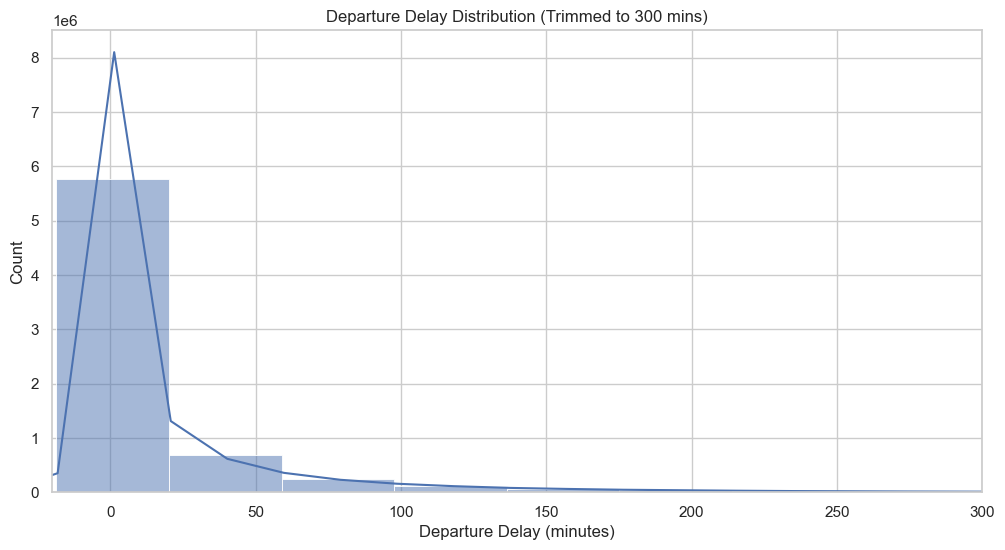

In [7]:
plt.figure(figsize=(12,6))
sns.histplot(df["dep_delay"].dropna(), bins=100, kde=True)
plt.xlim(-20, 300)
plt.title("Departure Delay Distribution (Trimmed to 300 mins)")
plt.xlabel("Departure Delay (minutes)")
plt.show()


Insight
- Average delays alone do not show the full picture, so I analyzed the distribution of delays to understand how delays are spread.

Result
- The delay distribution shows that most flights experience small delays or early departures, but there is a long tail of extreme delays reaching up to several hours.

- This indicates that while many flights are close to schedule, a smaller group of flights experiences severe disruptions.

Solution
- Operational strategies should focus on reducing extreme delays, since they have the largest impact on passengers and airline costs.

### 5. Top Airports Causing Departure Delays

Top 15 Worst Airports (Avg Departure Delay):
origin
MGW    72.621622
EWN    68.404255
HTS    42.788835
SMX    40.509434
CKB    37.024752
OTH    35.348974
HGR    35.118467
PBG    27.677755
HYA    26.636015
DEC    26.267717
ASE    26.226262
STX    25.730964
EAU    25.689655
USA    25.531295
MCW    24.731788
Name: dep_delay, dtype: float64


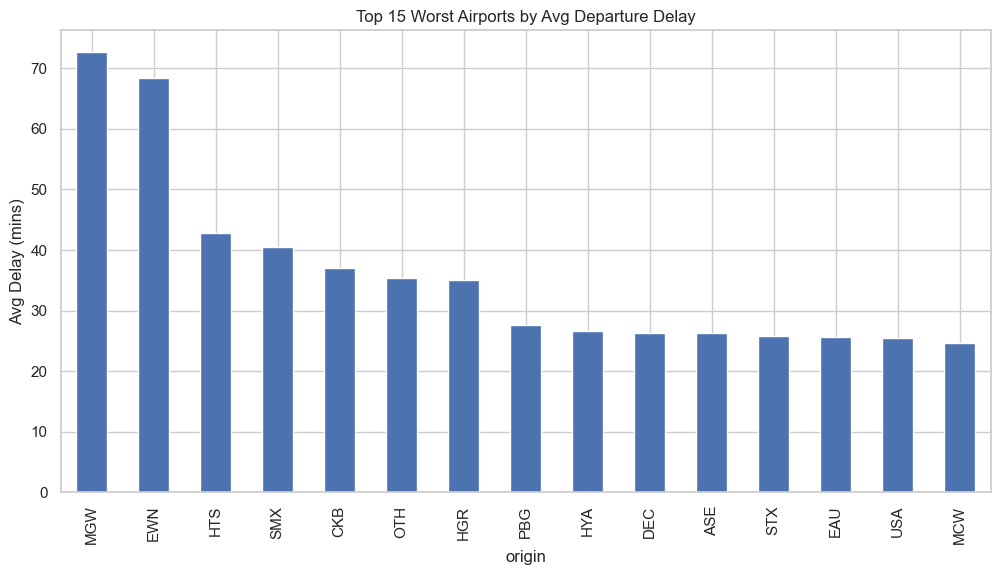

In [8]:
airport_delay = df.groupby("origin")["dep_delay"].mean().sort_values(ascending=False).head(15)

print("Top 15 Worst Airports (Avg Departure Delay):")
print(airport_delay)

airport_delay.plot(kind="bar")
plt.title("Top 15 Worst Airports by Avg Departure Delay")
plt.ylabel("Avg Delay (mins)")
plt.show()


Insight
- Airport infrastructure and congestion can significantly impact flight delays, so I analyzed which airports experience the highest average departure delays.

Result
- Airports such as MGW, EWN, HTS, and SMX showed the highest average departure delays.

Solution
- These airports may require further investigation into factors such as: runway capacity, ground operations efficiency, scheduling congestion

- Improving operations at these airports could significantly reduce overall delays.

### 6. Best Airports (Most Reliable)

Top 15 Best Airports (Lowest Avg Delay):
origin
SCC   -7.059675
AKN   -6.432584
ADK   -6.062500
BTM   -4.975362
YAK   -3.229577
PIH   -3.078571
OTZ   -2.308140
WRG   -1.216783
SPN   -1.214286
TWF   -1.174785
OME   -0.928977
PSG   -0.647552
EKO   -0.060440
ALW    0.197719
CDV    0.349719
Name: dep_delay, dtype: float64


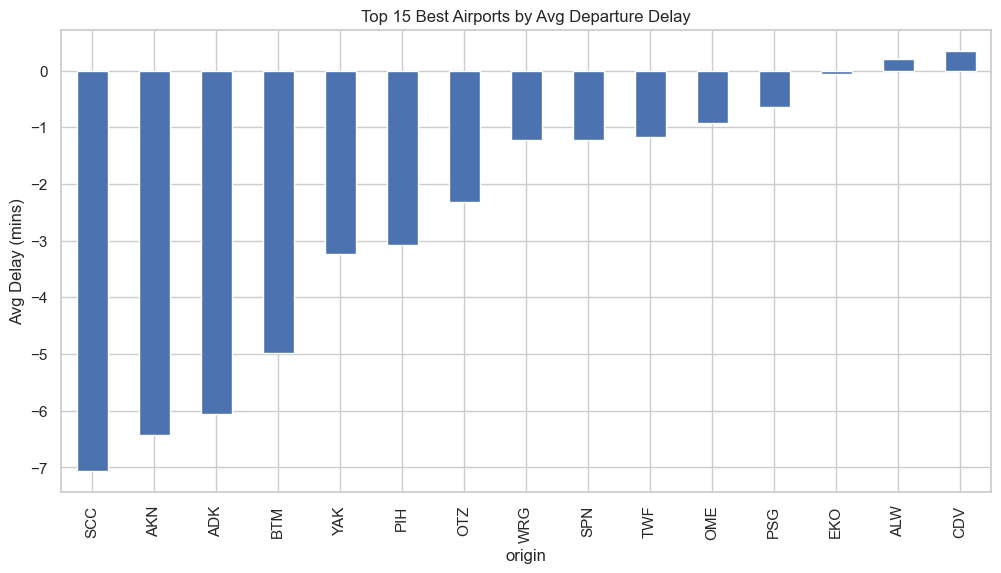

In [9]:
best_airports = df.groupby("origin")["dep_delay"].mean().sort_values().head(15)

print("Top 15 Best Airports (Lowest Avg Delay):")
print(best_airports)

best_airports.plot(kind="bar")
plt.title("Top 15 Best Airports by Avg Departure Delay")
plt.ylabel("Avg Delay (mins)")
plt.show()


Insight
- I also analyzed which airports demonstrate the best operational performance.

Result
- Airports such as SCC, AKN, and ADK have negative average delays, meaning flights often depart slightly earlier than scheduled.

Solution
- These airports can serve as operational benchmarks. Studying their processes may help identify best practices that could be applied to more congested airports.

### 7. Carrier Performance Analysis (Airline Reliability Ranking)

Carrier Delay Ranking:
op_unique_carrier
AA    20.698095
F9    19.002299
B6    17.458447
NK    14.957090
G4    14.047917
OH    13.936732
UA    11.959024
WN    11.748603
OO    11.279937
DL    10.223549
MQ    10.176118
9E     8.336984
AS     7.634071
HA     5.468065
YX     3.966759
Name: dep_delay, dtype: float64


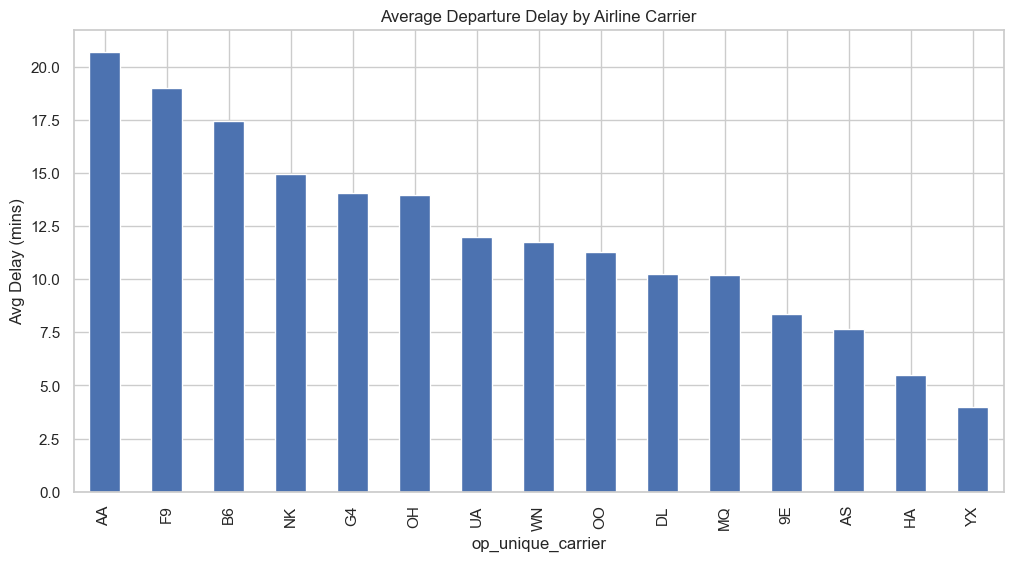

In [10]:
carrier_delay = df.groupby("op_unique_carrier")["dep_delay"].mean().sort_values(ascending=False)

print("Carrier Delay Ranking:")
print(carrier_delay)

carrier_delay.plot(kind="bar")
plt.title("Average Departure Delay by Airline Carrier")
plt.ylabel("Avg Delay (mins)")
plt.show()


Insight
- Airline operational strategies can influence delay performance, so I compared delay averages across different carriers.

Result
- Airlines such as AA, F9, B6, and NK showed higher average departure delays compared to others.

Solution
- These differences may be influenced by factors such as: route network complexity, airport congestion, aircraft rotation schedules

- Further analysis could help airlines optimize scheduling and fleet utilization.

### 8. Monthly Delay Trend (Seasonality + Peak Risk)

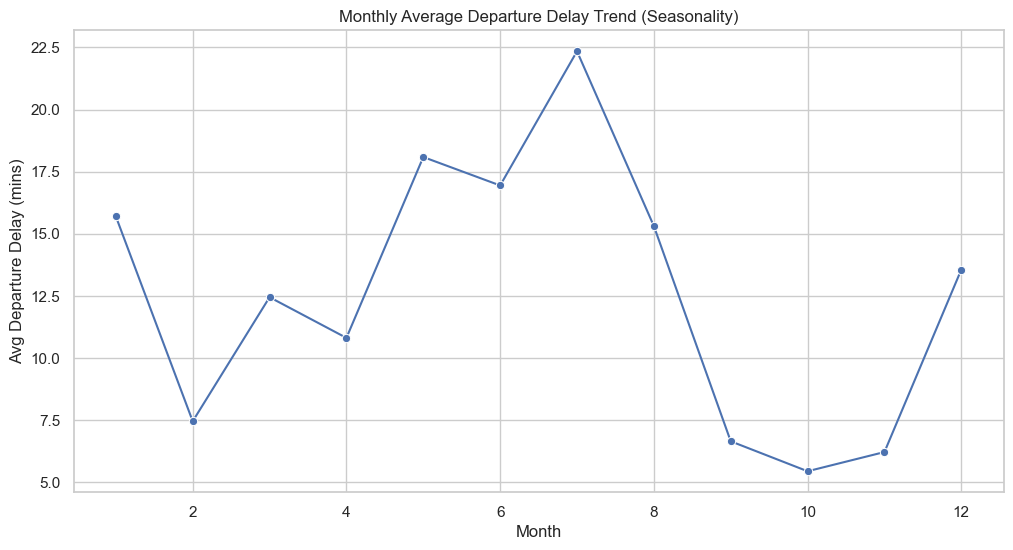

In [11]:
monthly_delay = df.groupby("month")["dep_delay"].mean()

sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker="o")
plt.title("Monthly Average Departure Delay Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Departure Delay (mins)")
plt.show()


Insight
- Flight delays often vary by season due to weather conditions and travel demand.

Result
- The monthly trend analysis shows noticeable fluctuations in delays across different months, suggesting seasonal effects.

Solution
- Airlines and airports should increase operational preparedness during high-risk months, especially when travel demand and weather disruptions are high.

### 9. Weekday Delay Trend (Business vs Weekend Travel)

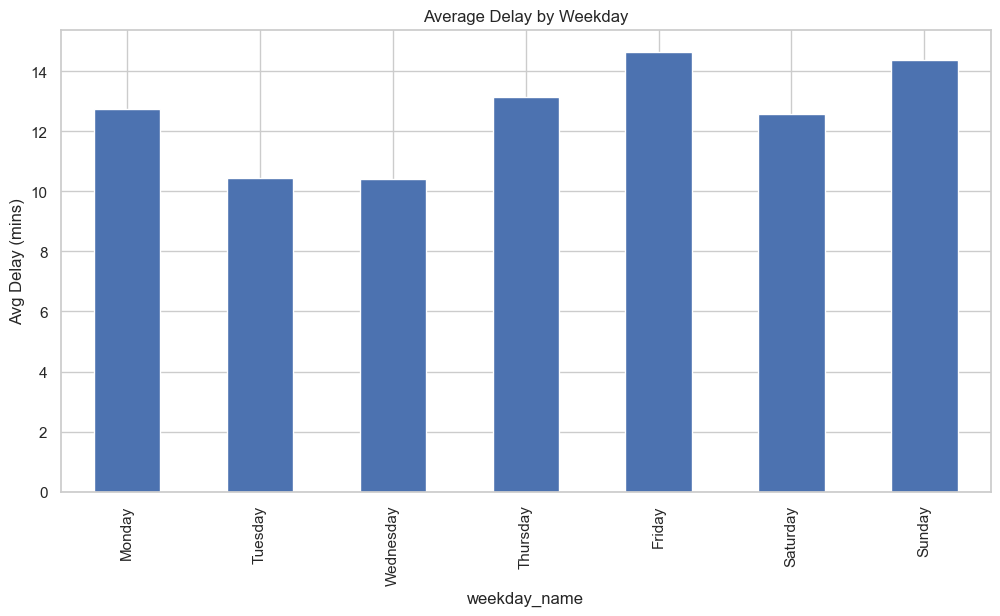

In [12]:
weekday_delay = df.groupby("weekday_name")["dep_delay"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)

weekday_delay.plot(kind="bar")
plt.title("Average Delay by Weekday")
plt.ylabel("Avg Delay (mins)")
plt.show()


Insight
- I analyzed delay patterns across days of the week to see if business travel patterns influence delays.

Result
- The results show variation in delays between weekdays and weekends.

Solution
- Understanding these patterns can help airlines optimize staffing and scheduling to handle higher traffic periods.

### 10. Best Time of Day to Fly (Major Insight)

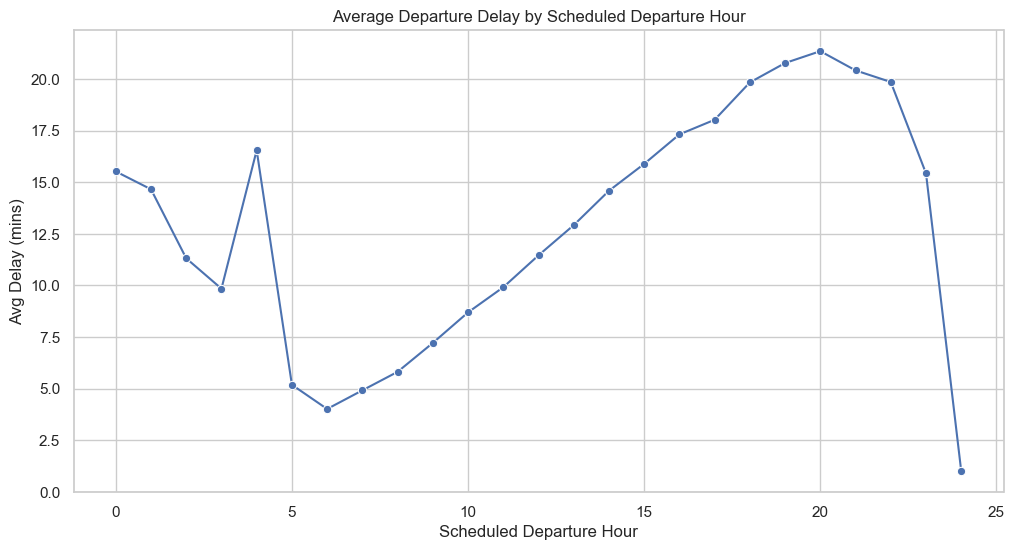

In [13]:
hourly_delay = df.groupby("crs_dep_hour")["dep_delay"].mean()

sns.lineplot(x=hourly_delay.index, y=hourly_delay.values, marker="o")
plt.title("Average Departure Delay by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Avg Delay (mins)")
plt.show()


Insight
- Flight delays often accumulate throughout the day as earlier delays propagate through the flight network.

Result
- Flights scheduled later in the day generally show higher average delays compared to early morning departures.

Solution
- Passengers who want to minimize delay risk should choose early morning flights, while airlines should focus on improving delay recovery later in the day.

### 11. Route Bottlenecks (Worst Origin → Destination Routes)

In [13]:
route_delay = df.groupby(["origin","dest"])["dep_delay"].mean().sort_values(ascending=False).head(20)

print("Worst 20 Routes by Avg Departure Delay:")
print(route_delay)


Worst 20 Routes by Avg Departure Delay:
origin  dest
JFK     LGA     765.000000
PHL     TTN     578.500000
SDF     SLC     363.000000
FAT     MRY     310.000000
IAD     MSN     309.000000
SRQ     IAH     253.833333
AVL     USA     240.000000
IAH     SDF     200.000000
MVY     CLT     180.272727
OKC     CAE     174.000000
LAX     ATW     168.500000
ATW     LAX     165.500000
RAP     XWA     121.000000
BGR     FLL     119.400000
HDN     BOS     115.806452
SDF     IAH     112.600000
OMA     EWR     108.000000
EUG     OTH     103.000000
BLV     FLL     102.875000
PGD     SAV     102.705882
Name: dep_delay, dtype: float64


Insight
- Some origin-destination routes experience more delays than others due to congestion or operational challenges.

Result
- Routes such as JFK–LGA and PHL–TTN showed extremely high average delays.

Solution
- These routes may require adjustments such as: improved scheduling buffers, optimized aircraft rotations, better airport coordination

### 12. Cancellation & Diversion Analysis (High Impact)

Cancellation Rate: 1.36%
Diversion Rate: 0.25%


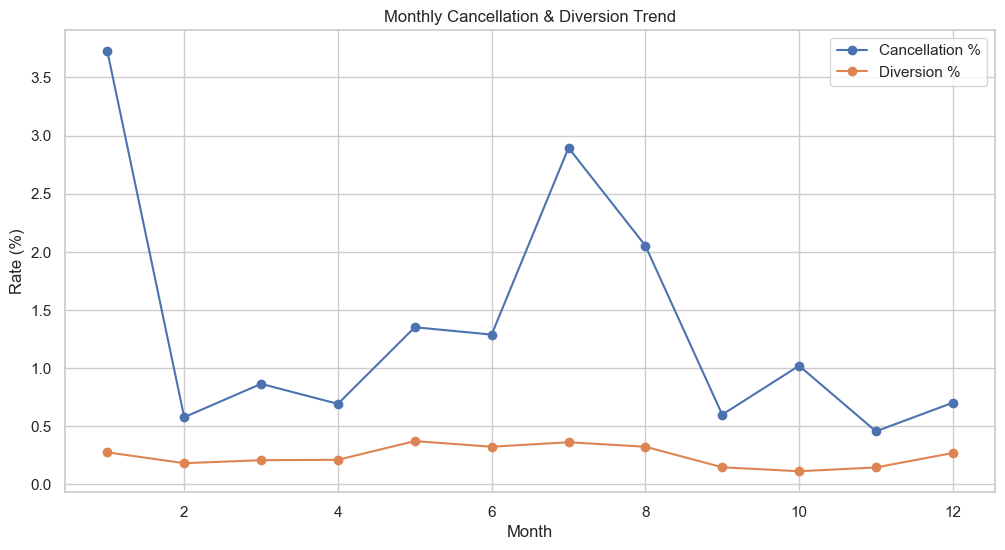

In [14]:
cancel_rate = df["cancelled"].mean() * 100
divert_rate = df["diverted"].mean() * 100

print(f"Cancellation Rate: {cancel_rate:.2f}%")
print(f"Diversion Rate: {divert_rate:.2f}%")

cancel_by_month = df.groupby("month")["cancelled"].mean() * 100
divert_by_month = df.groupby("month")["diverted"].mean() * 100

plt.plot(cancel_by_month.index, cancel_by_month.values, marker="o", label="Cancellation %")
plt.plot(divert_by_month.index, divert_by_month.values, marker="o", label="Diversion %")
plt.title("Monthly Cancellation & Diversion Trend")
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.legend()
plt.show()


Insight
- Beyond delays, cancellations and diversions represent the most disruptive outcomes for passengers.

Result

- Cancellation rate ≈ 1.36%

- Diversion rate ≈ 0.25%

- Although these percentages are relatively small, they still affect thousands of flights.

Solution
- Airlines should focus on improving operational resilience to reduce these disruptions.

### 13. Delay Cause Breakdown (Root Cause Analysis)

Total Delay Minutes by Cause:
late_aircraft_delay    41974007
carrier_delay          35823265
nas_delay              19621994
weather_delay           6195873
security_delay           179928
dtype: int64


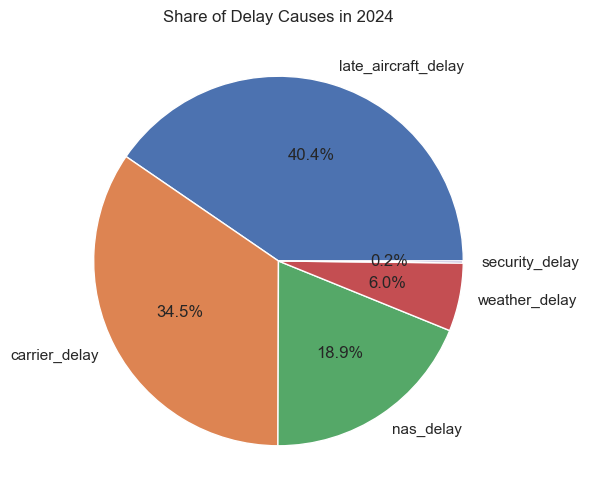

In [15]:
delay_cols = ["carrier_delay", "weather_delay", "nas_delay", "security_delay", "late_aircraft_delay"]

cause_sum = df[delay_cols].sum().sort_values(ascending=False)

print("Total Delay Minutes by Cause:")
print(cause_sum)

cause_sum.plot(kind="pie", autopct="%1.1f%%")
plt.title("Share of Delay Causes in 2024")
plt.ylabel("")
plt.show()


Insight
- Understanding the causes of delays is critical for identifying where operational improvements should be focused.

Result
- The largest contributors to delay minutes are: Late aircraft delay, Carrier delay, NAS (National Airspace System) delay

- Security delays contribute only a very small portion.

Solution
- Improving aircraft turnaround efficiency and better managing aircraft rotations could significantly reduce overall delays.

### 14. Airport Delay Cause Heatmap (Most Powerful Insight)

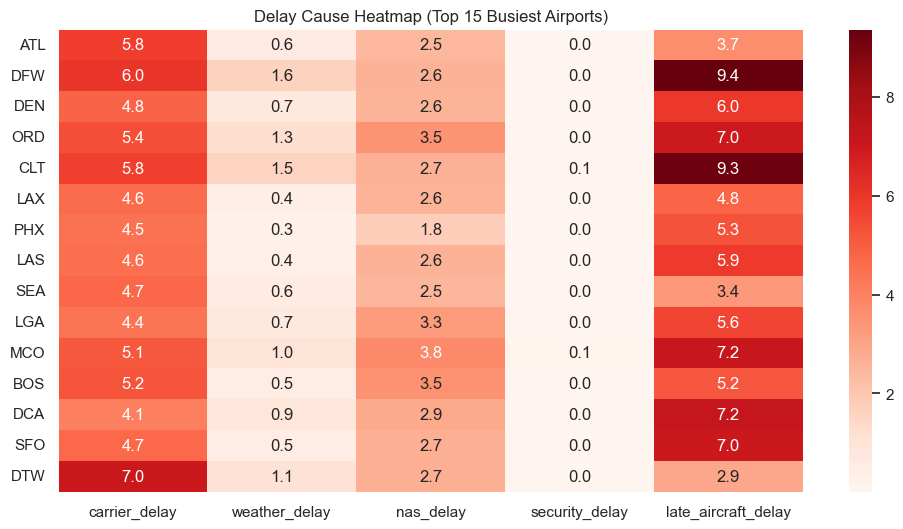

In [16]:
airport_cause = df.groupby("origin")[delay_cols].mean()

top_airports = df["origin"].value_counts().head(15).index
airport_cause_top = airport_cause.loc[top_airports]

plt.figure(figsize=(12,6))
sns.heatmap(airport_cause_top, annot=True, fmt=".1f", cmap="Reds")
plt.title("Delay Cause Heatmap (Top 15 Busiest Airports)")
plt.show()


Insight
- Different airports experience delays due to different reasons, so I compared delay causes across major airports.

Result
- The heatmap highlights how delay causes vary by airport.

Solution
- This analysis can help develop airport-specific operational strategies instead of applying a single solution to all airports.

### 15. Distance vs Delay (Are Longer Flights More Delayed?)

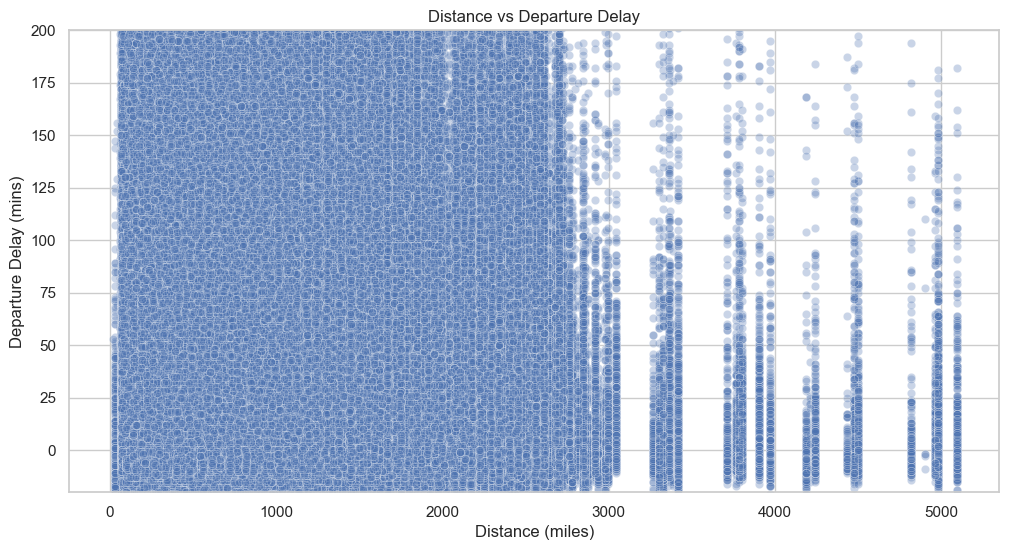

Correlation Distance vs Dep Delay: 0.014952002981605782


In [17]:
sns.scatterplot(x=df["distance"], y=df["dep_delay"], alpha=0.3)
plt.title("Distance vs Departure Delay")
plt.xlabel("Distance (miles)")
plt.ylabel("Departure Delay (mins)")
plt.ylim(-20, 200)
plt.show()

print("Correlation Distance vs Dep Delay:", df["distance"].corr(df["dep_delay"]))


Insight
- I tested whether longer flights are more likely to experience delays.

Result
- The correlation between flight distance and departure delay is very close to zero, indicating almost no relationship.

Solution
- This suggests that distance alone is not a major factor in flight delays, and operational factors are much more influential.

### 16. Taxi Time Analysis (Airport Congestion KPI)

Worst Airports for Taxi-Out (Runway Congestion):
origin
JFK    26.313878
GUC    24.791418
EWR    24.293652
BGM    24.233803
ORD    23.791638
LGA    23.456019
HDN    23.295181
XWA    22.988666
ASE    22.285269
EAR    22.156863
DRO    22.138295
CRW    21.931604
CIU    21.768802
CLT    21.689808
SAN    21.477660
Name: taxi_out, dtype: float64


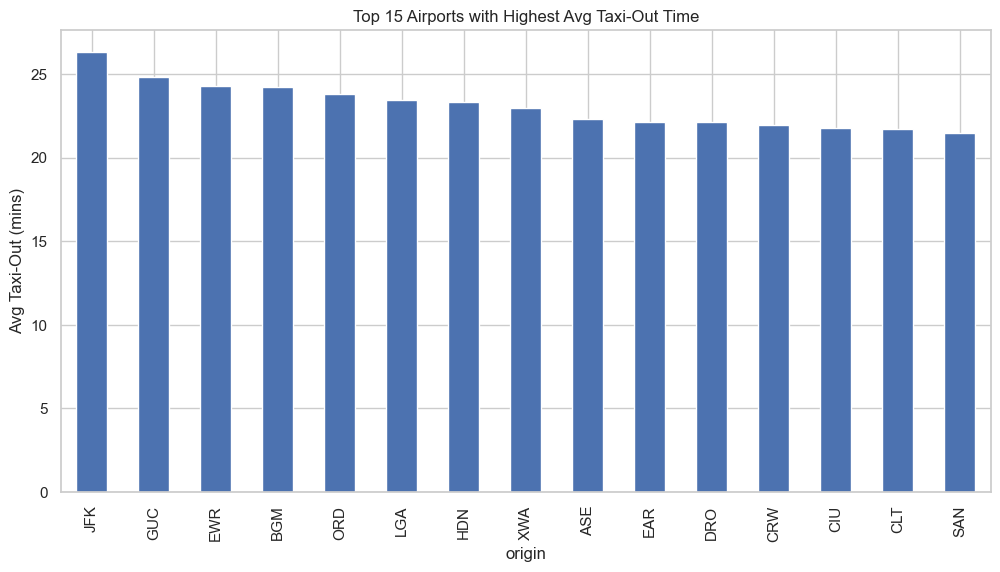

In [18]:
df["total_taxi_time"] = df["taxi_out"] + df["taxi_in"]

taxi_airport = df.groupby("origin")["taxi_out"].mean().sort_values(ascending=False).head(15)

print("Worst Airports for Taxi-Out (Runway Congestion):")
print(taxi_airport)

taxi_airport.plot(kind="bar")
plt.title("Top 15 Airports with Highest Avg Taxi-Out Time")
plt.ylabel("Avg Taxi-Out (mins)")
plt.show()


Insight
- Taxi-out time is an important indicator of airport congestion and runway efficiency.

Result
- Airports such as JFK, EWR, and ORD show the highest taxi-out times.

Solution
- Reducing taxi congestion through better runway management and improved ground operations could reduce departure delays.

### 17. Delay Propagation Analysis (Most Important Airline Problem)

Late Aircraft Delay Propagation % by Carrier:
op_unique_carrier
F9    17.881452
AA    15.260600
WN    14.084143
B6    13.245270
OH    12.502906
MQ    11.941562
G4    11.526320
AS     9.583067
UA     8.811087
9E     8.019231
NK     7.663642
HA     7.656946
DL     6.955848
YX     5.466970
OO     3.922203
Name: late_aircraft_flag, dtype: float64


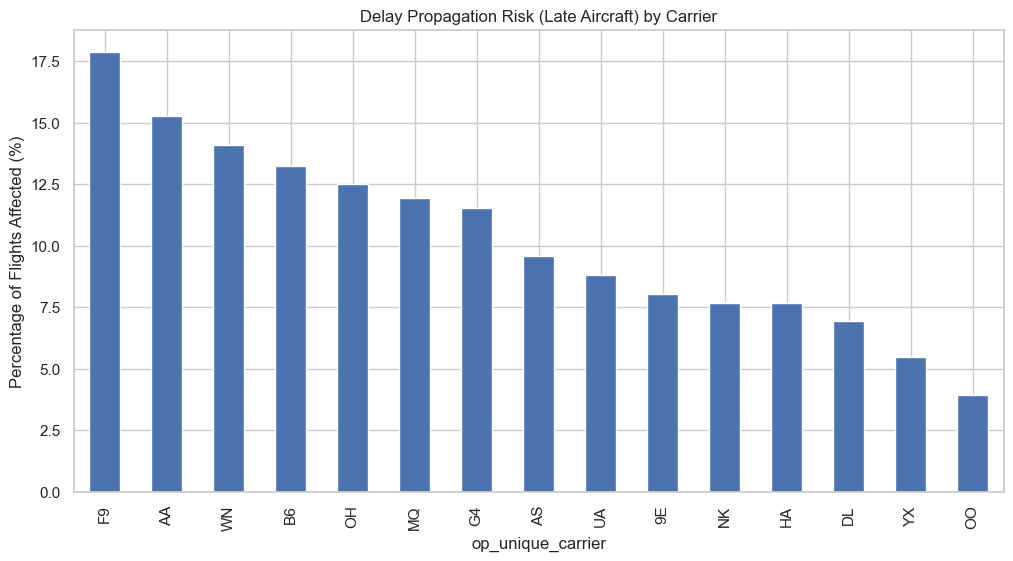

In [19]:
df["late_aircraft_flag"] = (df["late_aircraft_delay"] > 0).astype(int)

late_aircraft_rate = df.groupby("op_unique_carrier")["late_aircraft_flag"].mean().sort_values(ascending=False) * 100

print("Late Aircraft Delay Propagation % by Carrier:")
print(late_aircraft_rate)

late_aircraft_rate.plot(kind="bar")
plt.title("Delay Propagation Risk (Late Aircraft) by Carrier")
plt.ylabel("Percentage of Flights Affected (%)")
plt.show()


Insight
- A major contributor to delays is the late arrival of aircraft from previous flights, which creates a chain reaction.

Result
- Some airlines show higher rates of delay propagation due to late arriving aircraft.

Solution
- Improving aircraft turnaround efficiency and adding schedule buffers could help reduce delay propagation.

### 18. Financial Cost Estimation of Delays (REAL WORLD INSIGHT)

Assumption: each minute delay costs airline ~$75 (fuel, staff, gate, compensation)

Estimated Total Delay Cost: $8,370,239,625
Estimated Avg Cost per Flight: $1,198.13
Top 10 Airlines by Estimated Delay Cost:
op_unique_carrier
AA    1.703226e+09
WN    1.432083e+09
DL    1.015476e+09
UA    8.640041e+08
OO    8.585350e+08
B6    3.791089e+08
F9    3.584044e+08
NK    3.520232e+08
OH    3.115798e+08
MQ    2.764222e+08
Name: delay_cost, dtype: float64


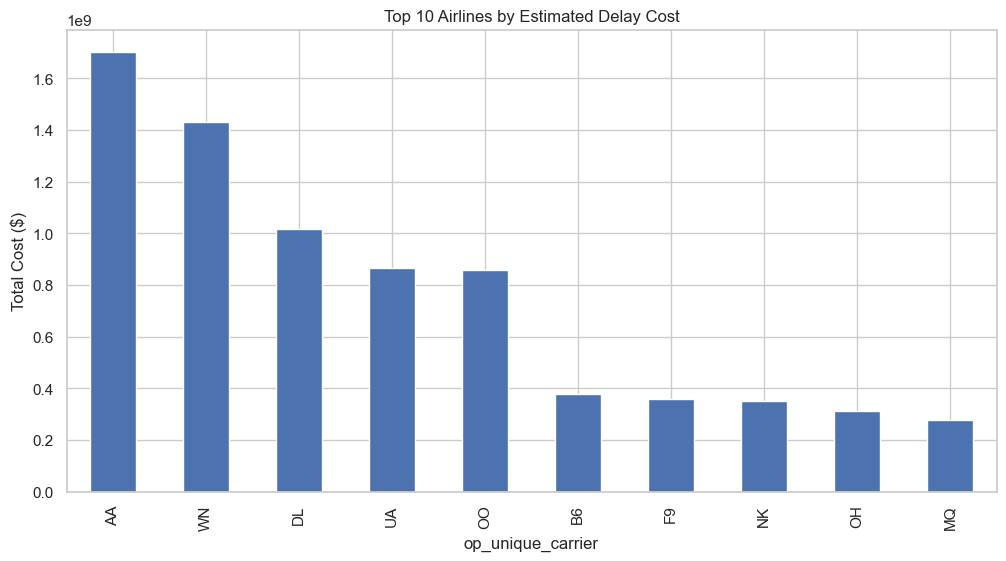

In [20]:
COST_PER_MIN = 75

df["delay_cost"] = df["dep_delay"].clip(lower=0) * COST_PER_MIN

total_cost = df["delay_cost"].sum()
avg_cost = df["delay_cost"].mean()

print(f"Estimated Total Delay Cost: ${total_cost:,.0f}")
print(f"Estimated Avg Cost per Flight: ${avg_cost:,.2f}")

cost_by_carrier = df.groupby("op_unique_carrier")["delay_cost"].sum().sort_values(ascending=False).head(10)

print("Top 10 Airlines by Estimated Delay Cost:")
print(cost_by_carrier)

cost_by_carrier.plot(kind="bar")
plt.title("Top 10 Airlines by Estimated Delay Cost")
plt.ylabel("Total Cost ($)")
plt.show()


Insight
- To understand the economic impact of delays, I estimated the cost of delay minutes using a cost-per-minute model.

Result
- Using an estimated cost of 75 dollars per delay minute, the total estimated delay cost reaches approximately 8.37 billion dollar.

Solution
- This estimate highlights the significant financial impact of delays. However, this is an estimated model rather than an audited financial value, and future analysis could refine it using airline-specific cost structures.

### 19. Identify High Risk Flights (Actionable for Operations)

In [21]:
high_risk = df[
    (df["crs_dep_hour"].between(17, 22)) &
    (df["month"].isin([6,7,8,12])) &
    (df["dep_delay"] > 30)
]

print("High Risk Flights Sample:")
print(high_risk[["fl_date","op_unique_carrier","origin","dest","dep_delay","crs_dep_hour"]].head(20))
print("High Risk Flights Count:", len(high_risk))


High Risk Flights Sample:
           fl_date op_unique_carrier origin dest  dep_delay  crs_dep_hour
2850221 2024-06-01                9E    CLT  LGA       70.0            17
2850421 2024-06-01                9E    LGA  BGR       82.0            17
2850602 2024-06-01                AA    DFW  MSY      176.0            19
2850606 2024-06-01                AA    DFW  STL       49.0            21
2850613 2024-06-01                AA    DCA  JAX       59.0            20
2850617 2024-06-01                AA    DFW  BFL       51.0            19
2850619 2024-06-01                AA    CLT  DFW      499.0            22
2850627 2024-06-01                AA    CLT  ORD       57.0            22
2850631 2024-06-01                AA    CLT  CLE       38.0            20
2850632 2024-06-01                AA    DFW  BNA      167.0            18
2850640 2024-06-01                AA    ATL  DFW     1012.0            18
2850643 2024-06-01                AA    MIA  BOS       58.0            21
2850646 2024

Insight
- Certain flights are more likely to experience delays based on time of day and season.

Result
- Flights departing between 17:00 and 22:00 during summer months and December show a higher probability of delays.

Solution
- This information can be used to develop early warning systems and operational planning strategies.

### 20. Build an Operational Dashboard Table (Export to Excel)

In [22]:
dashboard = df.groupby("origin").agg(
    total_flights=("origin","count"),
    avg_delay=("dep_delay","mean"),
    cancel_rate=("cancelled","mean"),
    divert_rate=("diverted","mean"),
    avg_taxi_out=("taxi_out","mean")
).sort_values("avg_delay", ascending=False)

dashboard["cancel_rate"] *= 100
dashboard["divert_rate"] *= 100

print(dashboard.head(20))

dashboard.to_excel("airport_performance_dashboard.xlsx")
print("Saved dashboard as airport_performance_dashboard.xlsx")


        total_flights  avg_delay  cancel_rate  divert_rate  avg_taxi_out
origin                                                                  
MGW                37  72.621622     0.000000     0.000000     18.162162
EWN                51  68.404255     7.843137     0.000000     15.851064
HTS               426  42.788835     3.286385     0.000000      9.669903
SMX               106  40.509434     0.000000     0.000000     11.509434
CKB               207  37.024752     2.415459     0.000000      9.534653
OTH               345  35.348974     1.159420     0.579710     15.486804
HGR               296  35.118467     3.040541     0.337838     11.261324
PBG               501  27.677755     3.992016     0.399202     16.216216
HYA               269  26.636015     3.345725     0.743494     17.357692
DEC               780  26.267717     2.307692     0.256410     13.620735
ASE              7888  26.226262     6.541582     0.824037     22.285269
STX              1196  25.730964     1.170569     0

Insight
- To summarize the results, I created an aggregated airport performance dashboard.

Result
- The dashboard includes key metrics such as: total flights, average delay, cancellation rate, diversion rate, taxi-out time

Solution
- This dashboard provides a clear overview of airport operational performance and can support data-driven decision making.

# Project Evaluation: 

The analysis successfully identifies major delay patterns, key contributing factors, and operational risks across airlines, airports, routes, and time periods. By examining delay causes, airport congestion, airline performance, and high-risk travel periods, this study provides actionable insights that can help improve operational planning and decision-making for airlines, airports, and passengers.

The following findings address the research questions defined in the project objective.

---

# 1. Which airlines and airports have the highest delay rates?

## Airlines with Higher Average Delays

The analysis shows that some airlines experience higher average departure delays than others.

**Airlines with the highest average departure delays include:**

- **AA (American Airlines)** – ~20.7 minutes  
- **F9 (Frontier Airlines)** – ~19 minutes  
- **B6 (JetBlue Airways)** – ~17.5 minutes  
- **NK (Spirit Airlines)** – ~15 minutes  

These airlines demonstrate relatively higher operational delays compared to other carriers.

---

## Airports with Highest Average Departure Delays

The airports with the largest departure delay averages include:

- **MGW – Morgantown Municipal Airport**
- **EWN – Coastal Carolina Regional Airport**
- **HTS – Tri-State Airport**
- **SMX – Santa Maria Public Airport**

These airports may experience operational inefficiencies, infrastructure limitations, or scheduling congestion that contribute to higher delays.

---

# 2. What time of day and season shows the worst delay patterns?

## Time of Day

The analysis indicates that **delays increase as the day progresses**.

Flights departing during the **evening hours (17:00–22:00)** show the highest delay probabilities.

This pattern occurs because delays accumulate throughout the day due to:

- Late arriving aircraft  
- Cascading operational disruptions  
- Airport congestion  

In contrast, **early morning flights tend to be the most reliable**.

---

## Seasonal Trends

Higher delay risks are observed during:

- **Summer months (June–August)**
- **December holiday season**

These periods experience higher passenger demand and increased weather disruptions, both of which contribute to operational delays.

---

# 3. What are the major causes of delays in 2024?

The analysis of delay causes reveals the following major contributors:

| Delay Cause | Impact |
|-------------|--------|
| Late Aircraft Delay | Largest contributor |
| Carrier Delay | Second largest |
| NAS (National Airspace System) Delay | Third largest |
| Weather Delay | Moderate contribution |
| Security Delay | Minimal impact |

### Key Finding

The **largest driver of delays is late arriving aircraft**, indicating that delays often propagate from previous flights within the airline network.

This suggests that improving **aircraft turnaround efficiency and scheduling buffers** could significantly reduce delays.

---

# 4. Which routes are most unreliable and risky?

The analysis identifies several routes with extremely high average delays.

**Examples include:**

- **JFK → LGA**
- **PHL → TTN**
- **SDF → SLC**
- **FAT → MRY**

These routes show unusually high average delays and may require operational adjustments such as:

- Improved scheduling buffers  
- Better coordination between airports  
- Optimized aircraft rotations  

---

# 5. How do delays impact operational costs and efficiency?

To estimate the financial impact of delays, a **cost-per-minute model** was applied.

## Key Results

- **Estimated cost per delay minute:** \$75  
- **Estimated total delay cost:** ~\$8.37 billion  
- **Average delay cost per flight:** ~\$1,198  

## Interpretation

These results demonstrate that delays have a **significant financial impact on airline operations**.

Reducing delay minutes could lead to:

- Lower operational costs  
- Improved aircraft utilization  
- Better passenger satisfaction  
- Improved airline reliability metrics  

---

# Final Conclusion

Overall, the analysis demonstrates that flight delays are influenced by a combination of **operational, network, and environmental factors**.

Key findings from the study include:

- Approximately **20% of flights experience significant delays**
- **Late aircraft propagation** is the largest contributor to delays
- **Evening flights and peak travel seasons** show the highest delay risk
- Certain **airports, airlines, and routes** consistently experience higher delay rates
- Delays generate **billions of dollars in operational costs**

By identifying these patterns, the analysis provides valuable insights that can support **improved scheduling strategies, operational efficiency, and delay mitigation efforts** for airlines and airports.